# Principal Component Analysis — CIBIL Credit Score Data
Standalone PCA exploration on the same dataset used for the Linear/Logistic Regression notebook. Goals:

1. Clean & preprocess the data the same way (so PCA sees the same feature space)
2. Fit PCA, look at explained variance / scree plot, and pick how many components to keep
3. Visualize the data in reduced PCA space, colored by `approved_flag`
4. Inspect loadings — which original features drive each principal component
5. Save everything (variance table, component scores, loadings) to CSV for later plotting
6. Bonus: a quick sanity check on whether PCA-reduced features lose much predictive signal

## 1. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.common.load_data import load_data, drop_targets, get_test_val_sets
from src.common.treat_missing import TabularPreprocessor, PreprocessConfig, load_and_process

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, f1_score

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RESULTS_DIR = Path("output/results_pca")
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Results will be written to: {RESULTS_DIR.resolve()}")

Results will be written to: /home/neeraj/Projects/ml_course/output/results_pca


In [3]:
pd.options.display.max_rows = 200

In [4]:
warnings.filterwarnings("ignore")

## 2. Load & Clean Data
Same source and same cleaning logic as the regression notebook, so the PCA feature space matches what those models saw.

In [5]:
df = load_data("./data/cibil_score/cibil_score.csv")
X, y_lin_reg, y_binary, y_multiclass = drop_targets(df)
X_train, X_val,  X_test, y_train, y_val, y_test = get_test_val_sets(X, y_binary, test_size=0.3)

0


## PCA Execution

In [6]:

# -------------------------
# Step 1: Standardize Data
# -------------------------
scaler = StandardScaler()
df_pca = df[['age', 'netmonthlyincome']]

X_std = scaler.fit_transform(df_pca)


X_std = pd.DataFrame(
    X_std,
    columns=df_pca.columns
)

print("\nStandardized Data")
print(X_std.round(3))

# -------------------------
# Step 2: Correlation Matrix
# -------------------------
corr = X_std.corr()

print("\nCorrelation Matrix")
print(corr.round(3))

# -------------------------
# Step 3: Covariance Matrix
# -------------------------
cov_matrix = np.cov(X_std.T)

print("\nCovariance Matrix")
print(np.round(cov_matrix,3))

# -------------------------
# Step 4: Eigen Values & Eigen Vectors
# -------------------------
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

print("\nEigen Values")
print(np.round(eigen_values,3))

print("\nEigen Vectors")
print(np.round(eigen_vectors,3))

# -------------------------
# Step 5: Sort Eigen Values
# -------------------------
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:,idx]

print("\nSorted Eigen Values")
print(np.round(eigen_values,3))

print("\nSorted Eigen Vectors")
print(np.round(eigen_vectors,3))

# -------------------------
# Step 6: Compute PC1 & PC2
# -------------------------
principal_components = np.dot(X_std, eigen_vectors)

pc_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

print("\nPrincipal Components")
print(pc_df.round(3))

# -------------------------
# Step 7: Explained Variance
# -------------------------
explained_variance = eigen_values / np.sum(eigen_values)

print("\nExplained Variance Ratio")
print(np.round(explained_variance,3))


Standardized Data
         age  netmonthlyincome
0      1.615             1.227
1     -1.220            -0.371
2      0.708            -1.319
3      0.027            -0.820
4      1.615            -0.570
...      ...               ...
51331  1.048            -0.396
51332 -0.313            -0.071
51333 -0.653            -0.421
51334 -0.993            -0.680
51335 -0.993            -0.521

[51336 rows x 2 columns]

Correlation Matrix
                    age  netmonthlyincome
age               1.000             0.084
netmonthlyincome  0.084             1.000

Covariance Matrix
[[1.    0.084]
 [0.084 1.   ]]

Eigen Values
[1.084 0.916]

Eigen Vectors
[[ 0.707 -0.707]
 [ 0.707  0.707]]

Sorted Eigen Values
[1.084 0.916]

Sorted Eigen Vectors
[[ 0.707 -0.707]
 [ 0.707  0.707]]

Principal Components
         PC1    PC2
0      2.010 -0.275
1     -1.125  0.601
2     -0.432 -1.433
3     -0.561 -0.599
4      0.739 -1.546
...      ...    ...
51331  0.461 -1.021
51332 -0.272  0.171
51333 -0.759  0

## Replace Missing Values

In [7]:
high_missing = [
    "cc_utilization",
    "pl_utilization"
]
median_columns = [
    "age_oldest_tl",
    "age_newest_tl",
    "pct_currentbal_all_tl",
    "time_since_recent_payment"
]
"""
Delinquency:
Features like num_times_30p_dpd or delinq_2yrs count how many 
separate instances a person crossed that late-payment threshold 
over a specific timeframe (such as the past 6 months, 12 months, or 2 years).
"""
delinquency_columns = [
    "max_delinquency_level",
    "max_deliq_6mts",
    "max_deliq_12mts",
    "time_since_recent_deliquency",
    "time_since_first_deliquency"
]

# If there is no entry means no enquiry
enquiry_columns = [
    "tot_enq",
    "cc_enq",
    "pl_enq",
    "cc_enq_l6m",
    "cc_enq_l12m",
    "pl_enq_l6m",
    "pl_enq_l12m",
    "enq_l3m",
    "enq_l6m",
    "enq_l12m"
]

# Maximum unsecured exposure = 0%
# Customer with no unsecured loan
max_unsecur = ["max_unsec_exposure_inpct"]

zero_cols = max_unsecur + enquiry_columns + delinquency_columns

log_transform_cols = ["netmonthlyincome"]

## 3. Preprocess (scale numeric, one-hot encode categorical)
PCA is scale-sensitive — without standardizing, high-magnitude columns (raw counts, income) would dominate the components purely because of their units. `StandardScaler` fixes that.

In [8]:
config = PreprocessConfig(
        high_missing=high_missing,
        median_cols=median_columns,
        zero_cols=zero_cols,
        log_transform_cols=log_transform_cols,
    )

In [9]:
preprocessor = TabularPreprocessor(config)
X_train_processed, X_val_processed, X_test_processed = preprocessor.fit_transform(
    X_train, X_val, X_test
)

2026-08-31 04:21:34,687 [INFO] src.common.treat_missing: Fitted median for 'age_oldest_tl' = 33.0
2026-08-31 04:21:34,690 [INFO] src.common.treat_missing: Fitted median for 'age_newest_tl' = 8.0
2026-08-31 04:21:34,694 [INFO] src.common.treat_missing: Fitted median for 'pct_currentbal_all_tl' = 0.623
2026-08-31 04:21:34,699 [INFO] src.common.treat_missing: Fitted median for 'time_since_recent_payment' = 74.0


2026-08-31 04:21:34,802 [INFO] src.common.treat_missing: Fitted no-enquiry fill value for 'time_since_recent_enq' = 4769
2026-08-31 04:21:34,994 [INFO] src.common.treat_missing: Fitted ColumnTransformer on 79 numeric and 5 categorical columns.
2026-08-31 04:21:34,994 [INFO] src.common.treat_missing: TabularPreprocessor fit complete.
2026-08-31 04:21:35,232 [INFO] src.common.treat_missing: Data processing complete! Ready for model training.


In [10]:
# preprocessor.fit_transform() returns plain numpy arrays, so at this
# point X_train_processed/X_val_processed/X_test_processed have no
# column names and no row index -- but later cells (loadings, PCA
# score tables) need both. Wrap each array back into a DataFrame using
# the fitted preprocessor's real output column names, and restore the
# original row index from X_train/X_val/X_test so joins against
# y_multiclass/y_binary/y_lin_reg (which are indexed by that same
# original index) line up correctly.
feature_names = preprocessor.get_feature_names()

for name, X_raw, X_proc in [
    ("X_train", X_train, X_train_processed),
    ("X_val", X_val, X_val_processed),
    ("X_test", X_test, X_test_processed),
]:
    if X_proc.shape[1] != len(feature_names):
        raise ValueError(
            f"{name}_processed has {X_proc.shape[1]} columns but "
            f"get_feature_names() returned {len(feature_names)} names; "
            f"the fitted preprocessor is out of sync with this array."
        )
    if X_proc.shape[0] != len(X_raw.index):
        raise ValueError(
            f"{name}_processed has {X_proc.shape[0]} rows but {name} "
            f"has {len(X_raw.index)}; cannot safely reattach the index."
        )

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_processed = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(f"Processed feature matrix: {X_train_processed.shape[0]} rows x "
      f"{X_train_processed.shape[1]} columns")
X_train_processed.head()

Processed feature matrix: 35935 rows x 97 columns


,num__prospectid,num__total_tl,num__tot_closed_tl,num__tot_active_tl,num__total_tl_opened_l6m,num__tot_tl_closed_l6m,num__pct_tl_open_l6m,num__pct_tl_closed_l6m,num__pct_active_tl,num__pct_closed_tl,...,cat__last_prod_enq2_CC,cat__last_prod_enq2_ConsumerLoan,cat__last_prod_enq2_HL,cat__last_prod_enq2_PL,cat__last_prod_enq2_others,cat__first_prod_enq2_CC,cat__first_prod_enq2_ConsumerLoan,cat__first_prod_enq2_HL,cat__first_prod_enq2_PL,cat__first_prod_enq2_others
29096,0.229743,-0.396291,-0.463663,-0.037541,0.204454,-0.432292,1.059088,-0.434361,1.114140,-1.114140,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
6062,-1.327811,6.830305,5.404733,7.365128,4.827178,3.618137,-0.183905,-0.072737,-0.594294,0.594294,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
14513,-0.756356,-0.118345,-0.463663,0.833361,-0.566000,-0.432292,-0.620632,-0.434361,1.114140,-1.114140,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5694,-1.352695,-0.535264,-0.463663,-0.472992,-0.566000,-0.432292,-0.620632,-0.434361,1.114140,-1.114140,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
34031,0.563447,-0.396291,-0.463663,-0.037541,-0.566000,-0.432292,-0.620632,-0.434361,1.114140,-1.114140,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## 4. Fit Full PCA — Explained Variance
Fit PCA with all components first (no `n_components` limit) purely to inspect how much variance each component captures, fit on **train only** to avoid leaking test information into the component directions.

In [11]:
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_train_processed)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

variance_df = pd.DataFrame({
    "component": np.arange(1, len(explained_variance_ratio) + 1),
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_variance_ratio": cumulative_variance,
})
variance_df.to_csv(RESULTS_DIR / "pca_explained_variance.csv", index=False)
variance_df.head(15)

,component,explained_variance_ratio,cumulative_variance_ratio
0,1,0.138546,0.138546
1,2,0.102954,0.241500
2,3,0.065719,0.307220
3,4,0.053647,0.360867
4,5,0.040765,0.401632
5,6,0.035787,0.437418
6,7,0.033042,0.470461
7,8,0.032142,0.502602
8,9,0.030449,0.533051
9,10,0.027262,0.560313


## 5. Scree Plot & Cumulative Variance

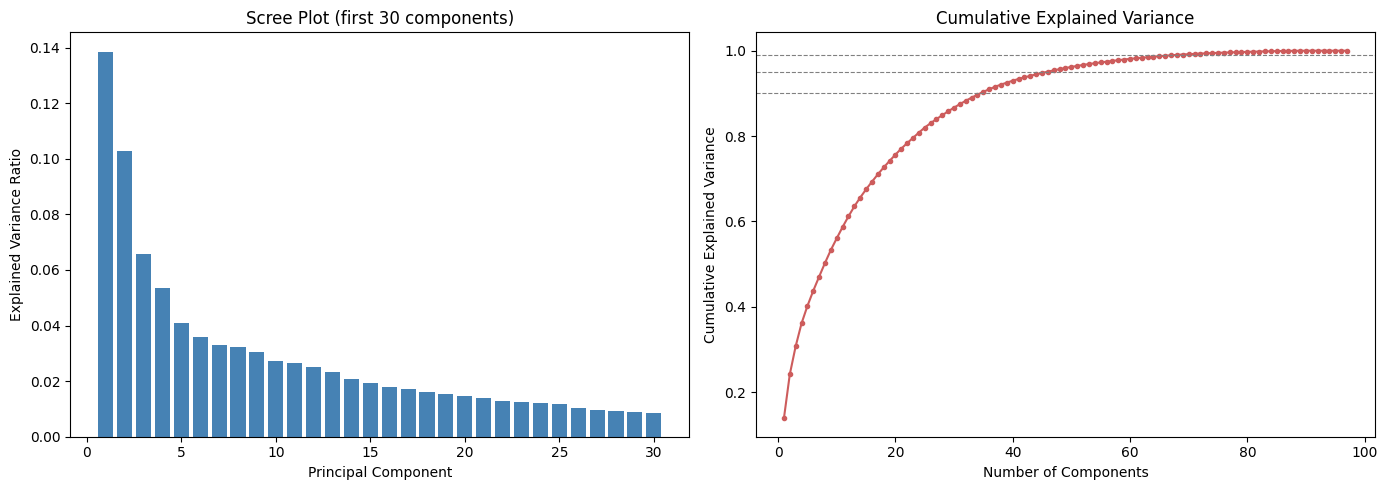

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(30, len(explained_variance_ratio))
axes[0].bar(variance_df["component"][:n_show], variance_df["explained_variance_ratio"][:n_show],
            color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (first 30 components)")

axes[1].plot(variance_df["component"], variance_df["cumulative_variance_ratio"],
             marker="o", markersize=3, color="indianred")
for threshold in [0.90, 0.95, 0.99]:
    axes[1].axhline(threshold, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")

plt.tight_layout()
plt.show()

## 6. Choose Number of Components
Number of components needed to reach common variance-retention thresholds.

In [13]:
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n_needed = int(np.searchsorted(cumulative_variance, threshold) + 1)
    print(f"{threshold:.0%} variance retained -> {n_needed} components "
          f"(of {X_train_processed.shape[1]} original features)")

N_COMPONENTS = int(np.searchsorted(cumulative_variance, 0.95) + 1)
print(f"\nUsing N_COMPONENTS = {N_COMPONENTS} (95% variance threshold) for the rest of this notebook.")

80% variance retained -> 24 components (of 97 original features)
90% variance retained -> 35 components (of 97 original features)
95% variance retained -> 46 components (of 97 original features)
99% variance retained -> 68 components (of 97 original features)

Using N_COMPONENTS = 46 (95% variance threshold) for the rest of this notebook.


## 7. Fit PCA With Chosen Components & Transform Data

In [21]:
print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(35935, 97)
(7700, 97)
(7701, 97)


In [23]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_processed)
X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

pc_columns = [f"PC{i+1}" for i in range(N_COMPONENTS)]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pc_columns, index=X_train_processed.index)
X_val_pca_df = pd.DataFrame(X_val_pca, columns=pc_columns, index=X_val_processed.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pc_columns, index=X_test_processed.index)

print(f"Reduced from {X_train_processed.shape[1]} -> {N_COMPONENTS} dimensions")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")

# Save component scores + original targets together, for later plotting/modeling
train_scores = X_train_pca_df.copy()
train_scores["approved_flag"] = y_multiclass.loc[X_train_pca_df.index].values
train_scores["approved_flag_binary"] = y_binary.loc[X_train_pca_df.index].values
train_scores["credit_score"] = y_lin_reg.loc[X_train_pca_df.index].values
train_scores["split"] = "train"

val_scores = X_val_pca_df.copy()
val_scores["approved_flag"] = y_multiclass.loc[X_val_pca_df.index].values
val_scores["approved_flag_binary"] = y_binary.loc[X_val_pca_df.index].values
val_scores["credit_score"] = y_lin_reg.loc[X_val_pca_df.index].values
val_scores["split"] = "val"

test_scores = X_test_pca_df.copy()
test_scores["approved_flag"] = y_multiclass.loc[X_test_pca_df.index].values
test_scores["approved_flag_binary"] = y_binary.loc[X_test_pca_df.index].values
test_scores["credit_score"] = y_lin_reg.loc[X_test_pca_df.index].values
test_scores["split"] = "test"

pca_scores_df = pd.concat([train_scores, val_scores, test_scores], axis=0)
pca_scores_df.to_csv(RESULTS_DIR / "pca_component_scores.csv", index=False)
print(f"Saved {len(pca_scores_df)} rows of PCA component scores to "
      f"{RESULTS_DIR / 'pca_component_scores.csv'}")
pca_scores_df.head()

Reduced from 97 -> 46 dimensions
Variance retained: 0.9510
Saved 51336 rows of PCA component scores to output/results_pca/pca_component_scores.csv


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,approved_flag,approved_flag_binary,credit_score,split
29096,-1.428591,-1.431134,-0.485224,2.693869,-0.329916,-0.541619,-0.160387,-0.242852,0.411031,0.176238,...,-0.875509,-0.378791,-0.115223,-0.026338,0.168436,0.107226,P2,1,669,train
6062,30.000742,-2.992949,-3.993200,-5.297307,-1.436670,-1.271751,0.236471,0.324927,0.473162,-4.854388,...,-1.350382,-3.203873,-0.520355,0.424767,1.544643,-2.880996,P3,0,665,train
14513,0.510693,-2.995070,0.397829,1.278609,0.538626,-0.782407,-0.147970,0.314626,-1.428224,-0.686492,...,-0.396078,-0.393471,-0.002323,0.007582,0.053943,0.383708,P4,0,650,train
5694,-0.720543,-2.574371,0.923723,0.247458,0.091528,-1.492619,-0.527051,0.239340,-2.010240,-0.429207,...,0.584668,0.055469,-0.200637,-0.103530,-0.083508,0.444360,P2,1,669,train
34031,-2.653698,-0.975741,0.322754,0.990564,-0.860555,0.226794,0.046838,-0.171997,0.334667,-0.506382,...,-0.518953,0.043675,0.000848,-0.023538,0.083050,0.184401,P2,1,686,train


In [25]:
# Reconfirmating number of rows in original dataset with pca dataset
X.shape

(51336, 85)

## 8. Visualize in Reduced PCA Space

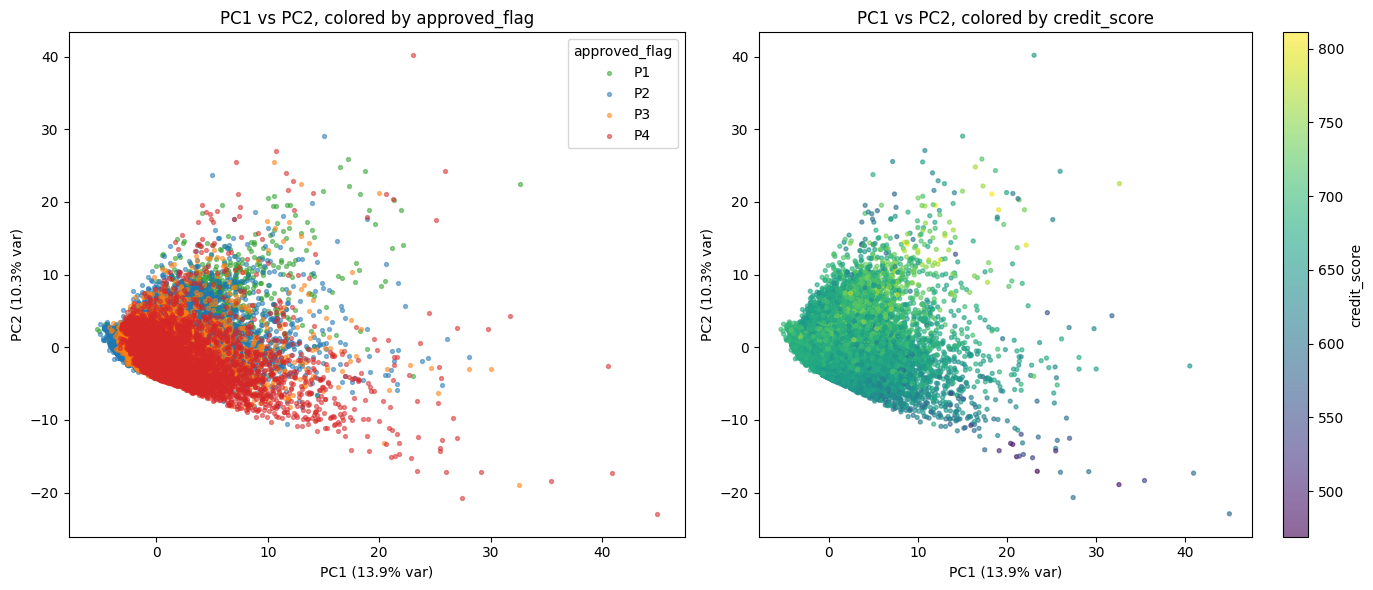

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palette = {"P1": "#2ca02c", "P2": "#1f77b4", "P3": "#ff7f0e", "P4": "#d62728"}
for flag, color in palette.items():
    mask = train_scores["approved_flag"] == flag
    axes[0].scatter(train_scores.loc[mask, "PC1"], train_scores.loc[mask, "PC2"],
                     s=8, alpha=0.5, label=flag, color=color)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
axes[0].set_title("PC1 vs PC2, colored by approved_flag")
axes[0].legend(title="approved_flag")

scatter = axes[1].scatter(train_scores["PC1"], train_scores["PC2"],
                           c=train_scores["credit_score"], cmap="viridis", s=8, alpha=0.6)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
axes[1].set_title("PC1 vs PC2, colored by credit_score")
plt.colorbar(scatter, ax=axes[1], label="credit_score")

plt.tight_layout()
plt.show()

## 9. Loadings — Which Original Features Drive Each Component
The loadings matrix (`pca.components_`) shows how much each original (scaled/encoded) feature contributes to each principal component. Sorting by absolute loading on a given component surfaces the features that define it.

In [27]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=pc_columns,
)
loadings.to_csv(RESULTS_DIR / "pca_loadings.csv")
print(f"Saved loadings matrix ({loadings.shape[0]} features x {loadings.shape[1]} components) to "
      f"{RESULTS_DIR / 'pca_loadings.csv'}")

TOP_N = 10
for pc in pc_columns[:5]:  # show the first 5 components
    top_features = loadings[pc].abs().sort_values(ascending=False).head(TOP_N).index
    print(f"\nTop {TOP_N} features driving {pc} "
          f"({pca.explained_variance_ratio_[pc_columns.index(pc)]:.1%} of variance):")
    print(loadings.loc[top_features, pc].sort_values(ascending=False))

Saved loadings matrix (97 features x 46 components) to output/results_pca/pca_loadings.csv

Top 10 features driving PC1 (13.9% of variance):
num__tot_enq                 0.241109
num__enq_l12m                0.222740
num__tot_active_tl           0.214739
num__total_tl_opened_l12m    0.214234
num__enq_l6m                 0.207974
num__pl_enq                  0.207323
num__unsecured_tl            0.204678
num__total_tl_opened_l6m     0.195748
num__pl_enq_l12m             0.191124
num__total_tl                0.186433
Name: PC1, dtype: float64

Top 10 features driving PC2 (10.3% of variance):
num__secured_tl                     0.206140
num__tot_closed_tl                  0.202196
num__num_times_delinquent           0.198035
num__num_times_30p_dpd              0.193116
num__time_since_first_deliquency    0.192944
num__pct_closed_tl                  0.188658
num__age_oldest_tl                  0.185379
num__pct_active_tl                 -0.188658
num__pct_of_active_tls_ever        -0.18865

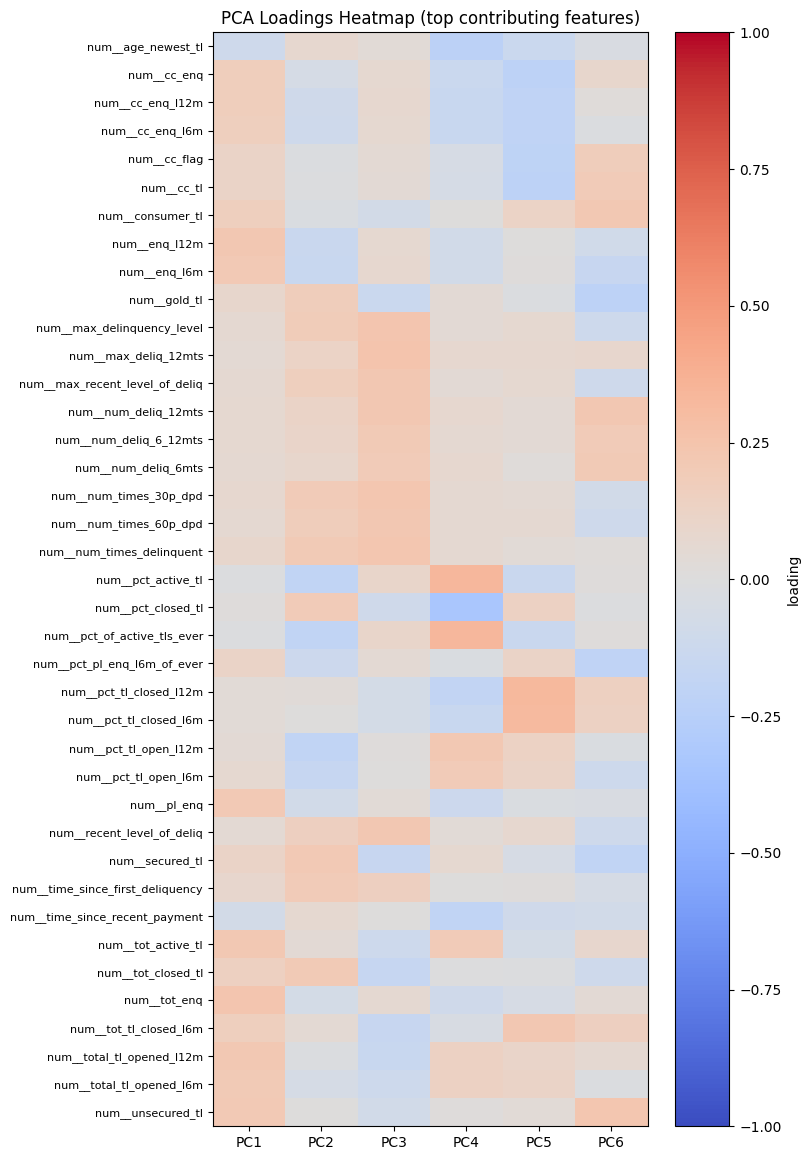

In [28]:
# Heatmap of the first N components x their top contributing features (union across components)
N_HEATMAP_COMPONENTS = min(6, N_COMPONENTS)
top_feature_union = set()
for pc in pc_columns[:N_HEATMAP_COMPONENTS]:
    top_feature_union.update(loadings[pc].abs().sort_values(ascending=False).head(8).index)
top_feature_union = sorted(top_feature_union)

heatmap_data = loadings.loc[top_feature_union, pc_columns[:N_HEATMAP_COMPONENTS]]

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(top_feature_union))))
im = ax.imshow(heatmap_data.values, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)
ax.set_title("PCA Loadings Heatmap (top contributing features)")
plt.colorbar(im, ax=ax, label="loading")
plt.tight_layout()
plt.show()

## 10. Bonus — Does PCA Lose Much Predictive Signal?
Quick sanity check: fit a plain Linear/Logistic Regression on the PCA-reduced features vs. the original full feature set. This isn't a rigorous model comparison (that lives in the regression notebook) — it's just a gut-check on how much signal the 95%-variance PCA reduction keeps.

In [ ]:
comparison_rows = []

# Linear regression: credit_score
lr_full = LinearRegression().fit(X_train_processed, y_lin_reg.loc[X_train_processed.index])
lr_pca = LinearRegression().fit(X_train_pca_df, y_lin_reg.loc[X_train_pca_df.index])
comparison_rows.append({
    "task": "linear (credit_score)", "feature_set": "original", "metric": "r2",
    "score": r2_score(y_lin_reg.loc[X_test_processed.index], lr_full.predict(X_test_processed)),
})
comparison_rows.append({
    "task": "linear (credit_score)", "feature_set": f"pca_{N_COMPONENTS}", "metric": "r2",
    "score": r2_score(y_lin_reg.loc[X_test_pca_df.index], lr_pca.predict(X_test_pca_df)),
})

# Logistic regression: approved_flag binary
log_full = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(
    X_train_processed, y_binary.loc[X_train_processed.index])
log_pca = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(
    X_train_pca_df, y_binary.loc[X_train_pca_df.index])
comparison_rows.append({
    "task": "logistic_binary (approved_flag)", "feature_set": "original", "metric": "accuracy",
    "score": accuracy_score(y_binary.loc[X_test_processed.index], log_full.predict(X_test_processed)),
})
comparison_rows.append({
    "task": "logistic_binary (approved_flag)", "feature_set": f"pca_{N_COMPONENTS}", "metric": "accuracy",
    "score": accuracy_score(y_binary.loc[X_test_pca_df.index], log_pca.predict(X_test_pca_df)),
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(RESULTS_DIR / "pca_vs_original_quick_comparison.csv", index=False)
comparison_df